In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
import matplotlib.gridspec as gridspec

plt.style.use('/aos/home/fstdenis/1D-SIM/sim1dplotting/science.mplstyle')

Those next sections are figures for the fully viscous case meaning that the stress tensor is given by 
$$ \sigma_{11} = \nu_{max}\frac{\partial u}{\partial x} - P$$

This first section reads the data. 

In [ ]:

#------- Viscous Experiment (1) -------#
datadict_viscous = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_1.npy', 
                              allow_pickle=True).item()
datadict_viscous_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_7.npy', 
                              allow_pickle=True).item()
datadict_viscous_energy = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_energy_saved_1.npy', 
                              allow_pickle=True).item()
datadict_viscous_energy_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_energy_saved_7.npy', 
                              allow_pickle=True).item()

datadict_viscous_vel = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_maxvel_1.npy', 
                              allow_pickle=True).item()
datadict_viscous_vel_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_maxvel_7.npy', 
                              allow_pickle=True).item()

#--- divergence ---#
divergence_tot, h_tot, A_tot, u_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_viscous.values()
divergence_tot_conv, h_tot_conv, A_tot_conv, u_tot_conv, eta_tot_conv, zeta_tot_conv, dt_conv, dx_conv, dates_conv, num_regime_conv = datadict_viscous_conv.values()


values = list(datadict_viscous_energy.values())
Plat_Tavg, Pfric_S_Tavg, Pfric_R_Tavg, Pfric_S_visc_Tavg, Pfric_R_visc_Tavg, \
Pfric_S_plas_Tavg, Pfric_R_plas_Tavg, P_fric_R_pZ_vE_Tavg, P_fric_R_vZ_pE_Tavg, \
Ph_Tavg, Pw_Tavg, Ppot_Tavg = values

# Ensure all arrays have the same length
fric_arrays = [ Pfric_R_visc_Tavg[0]]
min_len = min(arr.shape[0] for arr in fric_arrays)
P_fric = [arr[:min_len] for arr in fric_arrays]
P_fric_tot = np.sum(P_fric, axis=0)
print(len(P_fric_tot))

max_vel = datadict_viscous_vel['max']

#--- convergence ---#
values_conv = list(datadict_viscous_energy_conv.values())
Plat_Tavg_conv, Pfric_S_Tavg_conv, Pfric_R_Tavg_conv, Pfric_S_visc_Tavg_conv, Pfric_R_visc_Tavg_conv, \
Pfric_S_plas_Tavg_conv, Pfric_R_plas_Tavg_conv, P_fric_R_pZ_vE_Tavg_conv, P_fric_R_vZ_pE_Tavg_conv, \
Ph_Tavg_conv, Pw_Tavg_conv, Ppot_Tavg_conv = values_conv

P_fric_conv = [ Pfric_S_visc_Tavg_conv[0], Pfric_R_visc_Tavg_conv[0], \
Pfric_S_plas_Tavg_conv[0], Pfric_R_plas_Tavg_conv[0], P_fric_R_pZ_vE_Tavg_conv[0], P_fric_R_vZ_pE_Tavg_conv[0]]
min_len = min(arr.shape[0] for arr in P_fric_conv)
P_fric_conv = [arr[:min_len] for arr in P_fric_conv]
P_fric_conv_tot = np.sum(P_fric_conv, axis=0)
 
energy = [Plat_Tavg, Pfric_S_Tavg, Pfric_R_Tavg, Ph_Tavg, Pw_Tavg, Ppot_Tavg] 
energy_conv = [Plat_Tavg_conv, Pfric_S_Tavg_conv, Pfric_R_Tavg_conv, Ph_Tavg_conv, Pw_Tavg_conv, Ppot_Tavg_conv] 

max_vel_conv = datadict_viscous_vel_conv['max']


300000


Formating for plots

In [37]:
labels = [r'$P_{lat}$ (W/m$^2$)', r'$P_{f}^S$ (W/m$^2$)', r'$P_{f}^R$ (W/m$^2$)', r'$P_{h}$ (W/m$^2$)', r'$P_{w}$ (W/m$^2$)', r'$P_{pot}$ (W/m$^2$)']
time = np.arange(0, 299999)*dt/(60*60)

Nx = np.shape(divergence_tot)[1]
X = np.arange(0, Nx)*dx

norm = colors.Normalize(vmin=0, vmax=dates[-1])  # assuming k ranges from 0 to 10
cmap = plt.cm.viridis
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

sum_energy = np.sum(energy, axis = 0)
sum_energy_conv = np.sum(energy_conv, axis = 0)

This figure represents the energy for the divergent and convergent case as well as the maximum velocity for both cases. 

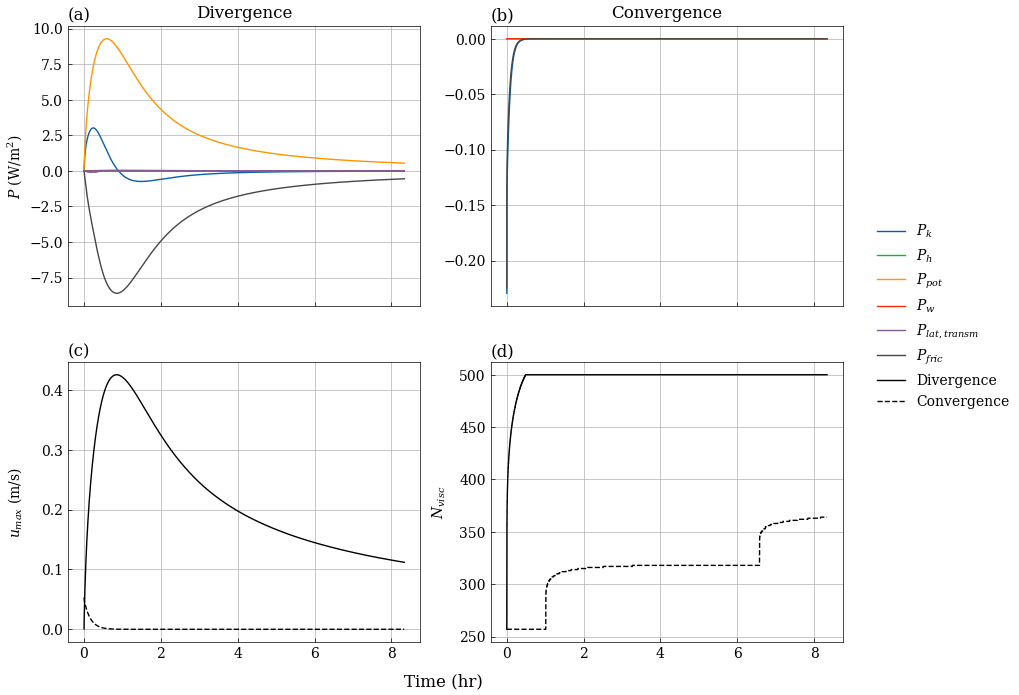

In [34]:

# Create 2x2 sub plots
gs = gridspec.GridSpec(2, 2)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (10, 8), sharex = True)

# fig = plt.figure(figsize = (8, 8))
# ax1 = fig.add_subplot(gs[0, 0]) # row 0, col 0


# ax2 = fig.add_subplot(gs[0, 1]) # row 0, col 1


# ax3 = fig.add_subplot(gs[1, :]) # row 1, span all columns

annotation_figs = ['(a)', '(b)', '(c)']
axs = [ax1, ax2, ax3, ax4]
Pfric_R_visc_Tavg[0][np.where(Pfric_R_visc_Tavg[0] == 0)[0]] = np.nan
linepk, = ax1.plot(time, sum_energy[0], label = r'$P_k$ ')
lineph, = ax1.plot(time, Ph_Tavg[0], label = r'$P_{h}$')
lineppot, = ax1.plot(time, Ppot_Tavg[0], label = r'$P_{pot}$')
linepw, = ax1.plot(time, Pw_Tavg[0], label = r'$P_{w}$')
lineplat, = ax1.plot(time, Plat_Tavg[0], label = r'$P_{lat, transm}$')
linepf, =ax1.plot(time, Pfric_R_Tavg[0], label = r'$P_{fric}$')
ax1.set_title('Divergence')


ax2.plot(time, sum_energy_conv[0], color=linepk.get_color())
ax2.plot(time, Ph_Tavg_conv[0], color=lineph.get_color())
ax2.plot(time, Ppot_Tavg_conv[0], color=lineppot.get_color())
ax2.plot(time, Pw_Tavg_conv[0], color=linepw.get_color())
ax1.plot(time, Plat_Tavg_conv[0], color=lineplat.get_color())
ax2.plot(time, Pfric_R_Tavg_conv[0], color=linepf.get_color())
ax2.set_title('Convergence')

ax3.plot(time, max_vel, color = 'k', label = 'Divergence')
ax3.plot(time, max_vel_conv, color = 'k', linestyle = '--',label = 'Convergence')

ax4.plot(time, num_regime[0], color = 'k')
ax4.plot(time, num_regime_conv[0], color = 'k', linestyle = '--')

fig.legend(loc = 'outside upper center', bbox_to_anchor = (1, 0.65))
for n, ax in enumerate(axs):
    ax.grid()
    
ax1.text(0.0, 1.02, '(a)' , transform=ax1.transAxes, size=12)
ax2.text(0.0, 1.02, '(b)' , transform=ax2.transAxes, size=12)
ax3.text(0.00, 1.02, '(c)' , transform=ax3.transAxes, size=12)
ax3.text(0.00, 1.02, '(d)' , transform=ax4.transAxes, size=12)

fig.supxlabel(r'Time (hr)', y = 0.05)
ax1.set_ylabel(r'$P$ (W/m$^2$)', x = 0.05)
ax3.set_ylabel(r'$u_{max}$ (m/s)', x = 0.05)
fig.align_ylabels()
ax4.set_ylabel(r'$N_{visc}$')
ax4.yaxis.set_label_coords(-0.12,0.5)

plt.savefig('Viscous_energy_tot.png')


This figure represents the time evolution of evolution and thickness

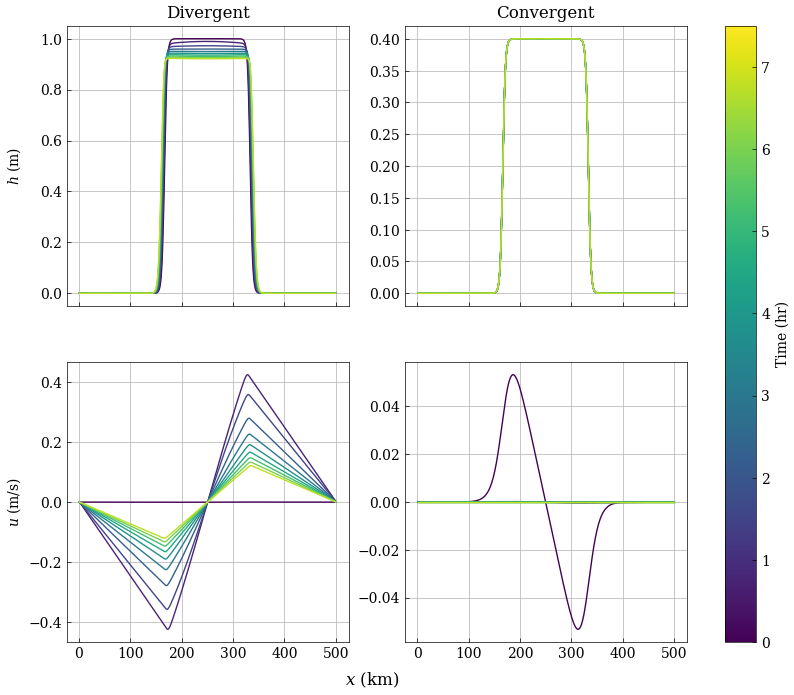

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (10, 8), sharex = True)

axs = [ax1, ax2, ax3, ax4]
c = 0
# for i, ax in enumerate(axs):
for ax in axs:
    ax.grid()

Nx = np.shape(divergence_tot)[1]
# ax.set_aspect('auto')

X = np.arange(0, Nx)*dx

for k, date in enumerate(dates):
    divergence = divergence_tot[k]
    h, A = h_tot[k], A_tot[k]
    u = u_tot[k]
    divergence_conv = divergence_tot_conv[k]
    h_conv, A_conv = h_tot_conv[k], A_tot_conv[k]
    u_conv = u_tot_conv[k]
    
    color = cmap(k/10)
    
    # if c > 0:
    ax3.plot(X[1:-1], u[:-1], label = '{}'.format(date), color = color)
    ax4.plot(X[1:-1], u_conv[:-1], label = '{}'.format(date), color = color)
    # else:
    ax1.plot(X[1:-1], h[1:-1], label = '{}'.format(date), color = color)
    ax2.plot(X[1:-1], h_conv[1:-1], label = '{}'.format(date), color = color)
       
    c +=1
    
fig.supxlabel(r'$x$ (km)',x = 0.43, y = 0.05)
fig.align_ylabels()
ax1.set_title('Divergent')
ax1.set_ylabel(r'$h$ (m)')
# fig.colorbar(sm, ax=axs, label = 'Time (hr)')
fig.colorbar(sm, ax=axs, label = 'Time (hr)')
ax3.set_ylabel(r'$u$ (m/s)')
ax2.set_title('Convergent')
fig.savefig('Viscous_numerical.png', dpi = 502)

This section treats the **Plastic** regime of both the VP and GC constitutive equations.

The VP plastic regime is given by 
$$ \sigma_{11} = \frac{\pm \sqrt{1+e^{-2}}-1}{2}P$$
and the GC plastic regime is given by 
$$\sigma_{11} = \left[\pm\left(\frac{\mu}{2}+\mu_b\right)-1\right]P$$

In [2]:
#------ VP Experiments -------#
datadict_lowres = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_2.npy', 
                              allow_pickle=True).item()
datadict_highres = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_8.npy', 
                              allow_pickle=True).item()
datadict_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_9.npy', 
                              allow_pickle=True).item()
datadict_viscous_energy_lowres = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_energy_saved_2.npy', 
                              allow_pickle=True).item()
datadict_viscous_energy_highres = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_energy_saved_8.npy', 
                              allow_pickle=True).item()

datadict_lowres_vel = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_maxvel_2.npy', 
                              allow_pickle=True).item()
datadict_highres_vel = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_maxvel_8.npy', 
                              allow_pickle=True).item()
datadict_conv_vel = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_maxvel_9.npy', 
                              allow_pickle=True).item()

datadict_viscous_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_9.npy', 
                              allow_pickle=True).item()
datadict_viscous_energy_conv = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_energy_saved_9.npy', 
                              allow_pickle=True).item()


divergence_tot, h_tot, A_tot, u_tot, sigma_tot, signorm_tot, \
eta_tot, zeta_tot, dt_low, dx_low, tstep_low, num_regime_low = datadict_lowres.values()

divergence_tot_high, h_tot_high, A_tot_high, u_tot_high, sigma_tot_high, signorm_tot_high, \
eta_tot_high, zeta_tot_high, dt_high, dx_high, tstep_high, num_regime_high = datadict_highres.values()

divergence_tot_conv, h_tot_conv, A_tot_conv, u_tot_conv,  sigma_tot_conv, signorm_tot_conv,\
eta_tot_conv, zeta_tot_conv, dt_conv, dx_conv, dates_conv, num_regime_conv = datadict_viscous_conv.values()


values = list(datadict_viscous_energy_lowres.values())
Plat_Tavg, Pfric_S_Tavg, Pfric_R_Tavg, Pfric_S_visc_Tavg, Pfric_R_visc_Tavg, \
Pfric_S_plas_Tavg, Pfric_R_plas_Tavg, P_fric_R_pZ_vE_Tavg, P_fric_R_vZ_pE_Tavg, \
Ph_Tavg, Pw_Tavg, Ppot_Tavg = values

# Ensure all arrays have the same length
fric_arrays = [ Pfric_R_visc_Tavg[0]]
min_len = min(arr.shape[0] for arr in fric_arrays)
P_fric = [arr[:min_len] for arr in fric_arrays]
P_fric_tot = np.sum(P_fric, axis=0)
print(len(P_fric_tot))

#--- High res ---#
values_high = list(datadict_viscous_energy_highres.values())
Plat_Tavg_high, Pfric_S_Tavg_high, Pfric_R_Tavg_high, Pfric_S_visc_Tavg_high, Pfric_R_visc_Tavg_high, \
Pfric_S_plas_Tavg_high, Pfric_R_plas_Tavg_high, P_fric_R_pZ_vE_Tavg_high, P_fric_R_vZ_pE_Tavg_high, \
Ph_Tavg_high, Pw_Tavg_high, Ppot_Tavg_high = values_high

P_fric_high = [ Pfric_S_visc_Tavg_high[0], Pfric_R_visc_Tavg_high[0], \
Pfric_S_plas_Tavg_high[0], Pfric_R_plas_Tavg_high[0], P_fric_R_pZ_vE_Tavg_high[0], P_fric_R_vZ_pE_Tavg_high[0]]
min_len = min(arr.shape[0] for arr in P_fric_high)
P_fric_high = [arr[:min_len] for arr in P_fric_high]
P_fric_high_tot = np.sum(P_fric_high, axis=0)

#--- High conv ---#
values_conv = list(datadict_viscous_energy_conv.values())
Plat_Tavg_conv, Pfric_S_Tavg_conv, Pfric_R_Tavg_conv, Pfric_S_visc_Tavg_conv, Pfric_R_visc_Tavg_conv, \
Pfric_S_plas_Tavg_conv, Pfric_R_plas_Tavg_conv, P_fric_R_pZ_vE_Tavg_conv, P_fric_R_vZ_pE_Tavg_conv, \
Ph_Tavg_conv, Pw_Tavg_conv, Ppot_Tavg_conv = values_conv

P_fric_conv = [ Pfric_S_visc_Tavg_conv[0], Pfric_R_visc_Tavg_conv[0], \
Pfric_S_plas_Tavg_conv[0], Pfric_R_plas_Tavg_conv[0], P_fric_R_pZ_vE_Tavg_conv[0], P_fric_R_vZ_pE_Tavg_conv[0]]
min_len = min(arr.shape[0] for arr in P_fric_conv)
P_fric_conv = [arr[:min_len] for arr in P_fric_conv]
P_fric_conv_tot = np.sum(P_fric_conv, axis=0)

 
energy = [Plat_Tavg, Pfric_S_Tavg, Pfric_R_Tavg, Ph_Tavg, Pw_Tavg, Ppot_Tavg] 
energy_high= [Plat_Tavg_high, Pfric_S_Tavg_high, Pfric_R_Tavg_high, Ph_Tavg_high, Pw_Tavg_high, Ppot_Tavg_high] 
energy_conv = [Plat_Tavg_conv, Pfric_S_Tavg_conv, Pfric_R_Tavg_conv, Ph_Tavg_conv, Pw_Tavg_conv, Ppot_Tavg_conv] 

sum_energy = np.sum(energy, axis = 0)
sum_energy_high = np.sum(energy_high, axis = 0)
sum_energy_conv = np.sum(energy_conv, axis = 0)

max_low = datadict_lowres_vel['max']
max_high = datadict_highres_vel['max']
max_conv = datadict_conv_vel['max']

#---- u and h ----#
Nx_low = np.shape(divergence_tot)[1]
X_low = np.arange(0, Nx_low)*dx_low

norm = colors.Normalize(vmin=0, vmax=tstep_low[-1])  # assuming k ranges from 0 to 10
cmap = plt.cm.viridis
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

299999


1
2
3
4
5
6
7
8
9


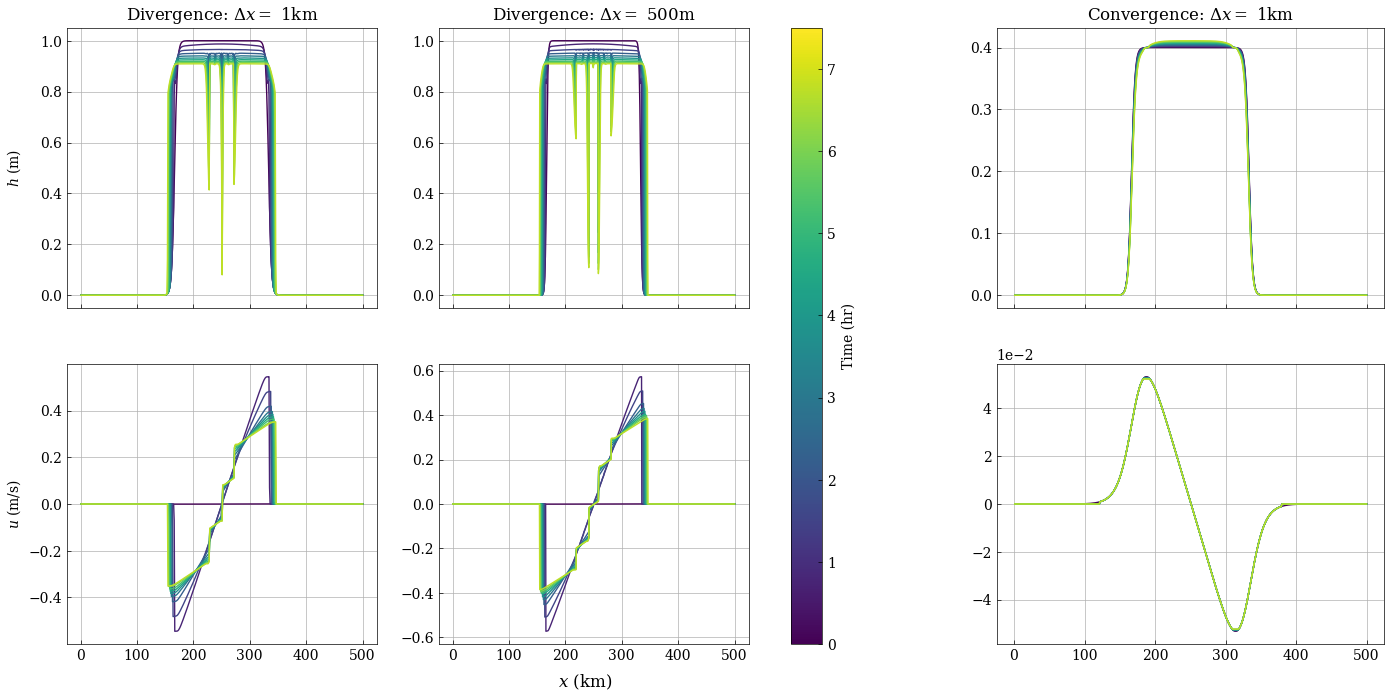

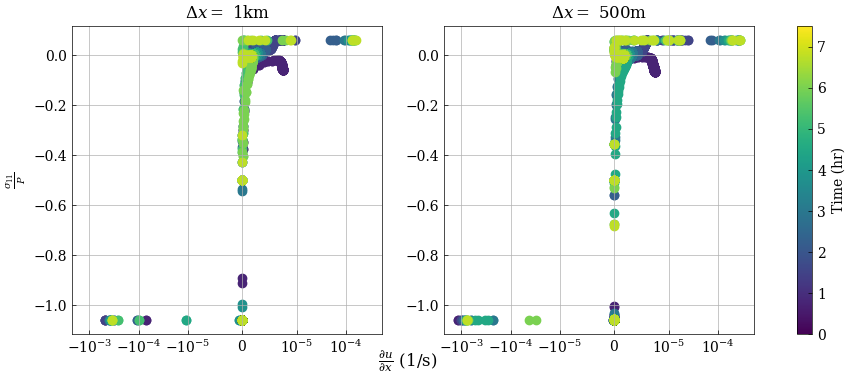

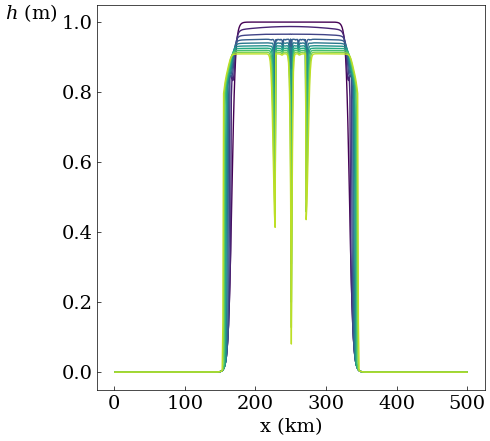

In [19]:
fig, ((ax1, ax2, ax7), (ax3, ax4, ax8)) = plt.subplots(2, 3, figsize = (17, 8), sharex = True)

fig2, (ax5, ax6) = plt.subplots(1, 2, figsize = (11, 4), sharex = True)

fig3, ax9 = plt.subplots(1, 1, figsize = (5, 5))

axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
c = 0
for i, ax in enumerate( axs, start=1):
    print(i)
    if i < 9:
        ax.grid()
 
    if i == 1 or i == 3 or i == 5 or i == 9:
        divergence_tot, h_tot, A_tot, u_tot,sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_lowres.values()
        Nx = np.shape(divergence_tot)[1]
	
    elif i == 2 or i == 4 or i == 6:
        divergence_tot, h_tot, A_tot, u_tot, sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_highres.values()
        Nx = np.shape(divergence_tot)[1]
    else:
        divergence_tot, h_tot, A_tot, u_tot, sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_conv.values()
        Nx = np.shape(divergence_tot)[1]
    
    X = np.arange(0, Nx)*dx
    
    for k, date in enumerate(dates):
        divergence = divergence_tot[k]
        h, A = h_tot[k], A_tot[k]
        u = u_tot[k]
        eta, zeta = eta_tot[k], zeta_tot[k]
        signorm = signorm_tot[k]
        
        color = cmap(k/10)
        

        if (i == 1) or (i == 2) or (i == 7) or i == 9:
            ax.plot(X[1:-1], h[1:-1], label = '{}'.format(date), color = color)
        elif i == 3 or i == 4 or i == 8:
            ax.plot(X[1:-1], u[:-1], label = '{}'.format(date), color = color)
        else:
            ax.scatter(divergence[1:-1], signorm[1:-1], label = '{}'.format(date), color = color)
       
    c +=1
    
fig.supxlabel(r'$x$ (km)', y = 0.05, x = 0.43)
fig.align_ylabels()
ax1.set_ylabel(r'$h$ (m)')
ax9.set_ylabel(r'$h$ (m)', rotation = 0, fontsize = 14)
ax.yaxis.set_label_coords(-0.17,0.95)
ax9.set_xlabel('x (km)', fontsize = 14)
ax9.tick_params(axis='both', labelsize=14)
ax1.set_title(r'Divergence: $ \Delta x = $ 1km')
ax2.set_title(r'Divergence: $\Delta x = $ 500m')
ax7.set_title(r'Convergence: $\Delta x = $ 1km')
ax8.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
fig.colorbar(sm, ax=axs[:4]+axs[-2:-2], label = 'Time (hr)')
ax3.set_ylabel(r'$u$ (m/s)')
fig.savefig('VP_numerical.png', dpi = 500)

fig2.supxlabel(r'$\frac{\partial u }{\partial x}$ (1/s)', y = 0.01, x = 0.43)
fig2.align_ylabels()
ax5.set_xscale('symlog', linthresh = 1e-5)
ax5.set_ylabel(r'$\frac{\sigma_{11}}{P}$')
ax5.set_title(r'$\Delta x = $ 1km')
ax6.set_title(r'$\Delta x = $ 500m')
fig.colorbar(sm, ax=axs[4:6], label = 'Time (hr)')
fig2.savefig('VP_numerical_signma.png', dpi = 500)
fig3.savefig('VP_1km.png')

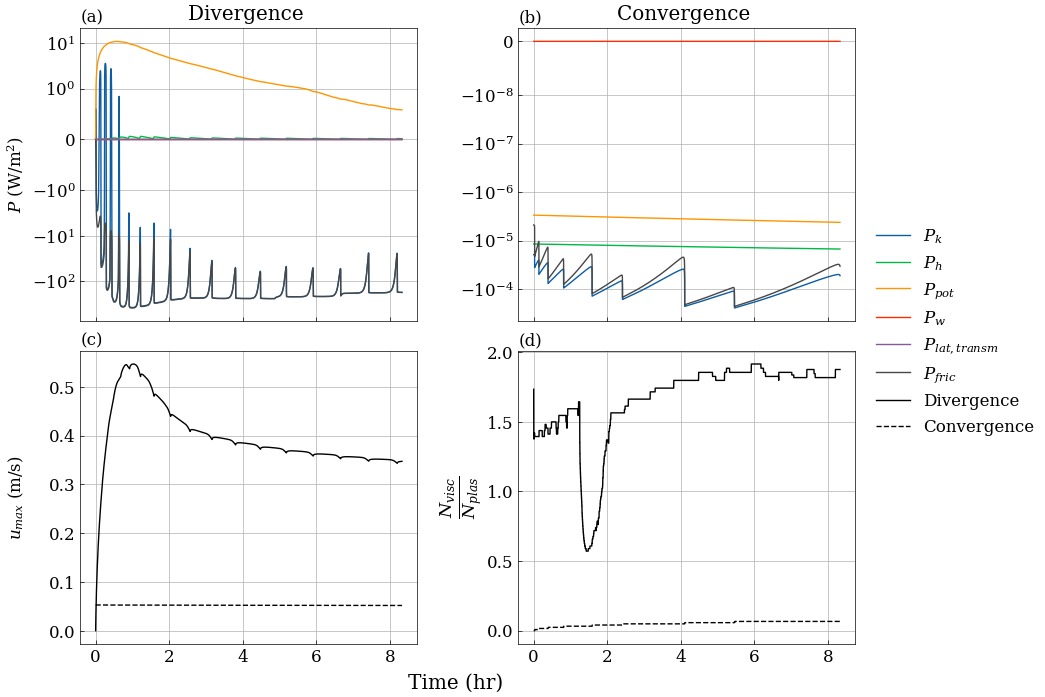

In [110]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (10, 8), sharex = True)

plt.rcParams.update({'font.size': 12})

axs = [ax1, ax2, ax3, ax4]
Pfric_R_visc_Tavg[0][np.where(Pfric_R_visc_Tavg[0] == 0)[0]] = np.nan
linepk, = ax1.plot(time, sum_energy[0], label = r'$P_k$ ')
lineph, = ax1.plot(time, Ph_Tavg[0], label = r'$P_{h}$')
lineppot, = ax1.plot(time, Ppot_Tavg[0], label = r'$P_{pot}$')
linepw, = ax1.plot(time, Pw_Tavg[0], label = r'$P_{w}$')
lineplat, = ax1.plot(time, Plat_Tavg[0], label = r'$P_{lat, transm}$')
linepf, =ax1.plot(time, Pfric_R_Tavg[0], label = r'$P_{fric}$')
ax1.set_title(r'Divergence ')


ax2.plot(time, sum_energy_conv[0], color=linepk.get_color())
ax2.plot(time, Ph_Tavg_conv[0], color=lineph.get_color())
ax2.plot(time, Ppot_Tavg_conv[0], color=lineppot.get_color())
ax2.plot(time, Pw_Tavg_conv[0], color=linepw.get_color())
ax1.plot(time, Plat_Tavg_conv[0], color=lineplat.get_color())
ax2.plot(time, Pfric_R_Tavg_conv[0], color=linepf.get_color())
ax2.set_title(r'Convergence ')

ax3.plot(time, max_low, color = 'k', label = r'Divergence')
ax3.plot(time, max_conv, color = 'k', linestyle = '--',label = r'Convergence')

ax4.plot(time, num_regime_low[0]/num_regime_low[1], color = 'k')
ax4.plot(time, num_regime_conv[0]/num_regime_conv[1], color = 'k', linestyle = '--')

fig.legend(loc = 'outside upper center', bbox_to_anchor = (1, 0.65))
for n, ax in enumerate(axs):
    ax.grid()
fig.subplots_adjust(wspace=0.3, hspace=0.1)
ax1.text(0.0, 1.02, '(a)' , transform=ax1.transAxes, size=12)
ax2.text(0.0, 1.02, '(b)' , transform=ax2.transAxes, size=12)
ax3.text(0.00, 1.02, '(c)' , transform=ax3.transAxes, size=12)
ax3.text(0.00, 1.02, '(d)' , transform=ax4.transAxes, size=12)

ax1.set_yscale('symlog', linthresh = 1)
ax2.set_yscale('symlog', linthresh = 1e-8)
fig.supxlabel(r'Time (hr)', y = 0.05)
ax1.set_ylabel(r'$P$ (W/m$^2$)', x = 0.05)
ax3.set_ylabel(r'$u_{max}$ (m/s)', x = 0.05)
fig.align_ylabels()
ax4.set_ylabel(r'$\frac{N_{visc}}{N_{plas}}$', size = 18)
ax4.yaxis.set_label_coords(-0.1,0.5)

plt.savefig('VP_energy_tot.png')

[     0      1      2 ... 299996 299997 299998]


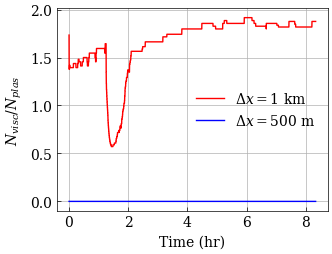

In [51]:
#---- number in viscous and plastic -----# 
tstep_tot = np.arange(0, np.shape(num_regime[0])[0])
print(tstep_tot)
plt.figure()
plt.plot(tstep_tot/(60*60)*dt, num_regime_low[0]/num_regime_low[1], linestyle = '-', color = 'r', label = r'$\Delta x = 1$ km')
plt.plot(tstep_tot/(60*60)*dt, num_regime_high[0]/num_regime_high[1], linestyle = '-', color = 'b',  label = r'$\Delta x = 500$ m')
plt.grid()
plt.legend()
plt.xlabel('Time (hr)')
plt.ylabel(r'$N_{visc}/N_{plas}$')
plt.savefig('number_regime_vicous.png')

In [11]:
datadict_mub = np.load('/aos/home/fstdenis/1D-SIM/sim1dplotting/SavedExperiments/datadict_exp_3.npy', 
                              allow_pickle=True).item()
divergence_tot, h_tot, A_tot, u_tot, sigma_tot, signorm_tot, \
eta_tot, zeta_tot, dt_low, dx_low, tstep_low, num_regime_low = datadict_mub.values()

Nx_low = np.shape(divergence_tot)[1]
X_low = np.arange(0, Nx_low)*dx_low

norm = colors.Normalize(vmin=0, vmax=tstep_low[-1])  # assuming k ranges from 0 to 10
cmap = plt.cm.viridis
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

1


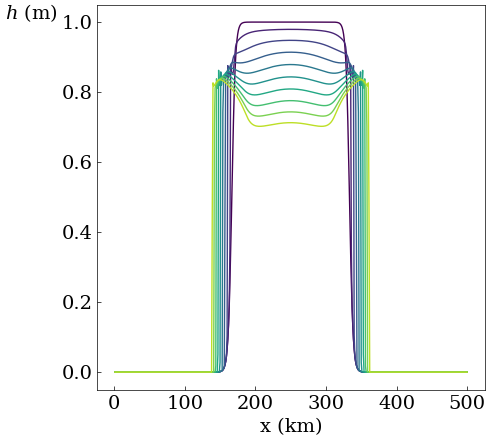

In [18]:


fig3, ax9 = plt.subplots(1, 1, figsize = (5, 5))

axs = [ax9]
c = 0
for i, ax in enumerate( axs, start=1):
    print(i)
    # if i < 9:
    #     ax.grid()
 
    # if i == 1 or i == 3 or i == 5 or i == 9:
    divergence_tot, h_tot, A_tot, u_tot,sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_mub.values()
    Nx = np.shape(divergence_tot)[1]

    # elif i == 2 or i == 4 or i == 6:
    #     divergence_tot, h_tot, A_tot, u_tot, sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_highres.values()
    #     Nx = np.shape(divergence_tot)[1]
    # else:
    #     divergence_tot, h_tot, A_tot, u_tot, sig_tot, signorm_tot, eta_tot, zeta_tot, dt, dx, dates, num_regime = datadict_conv.values()
    #     Nx = np.shape(divergence_tot)[1]
    
    X = np.arange(0, Nx)*dx
    
    for k, date in enumerate(dates):
        divergence = divergence_tot[k]
        h, A = h_tot[k], A_tot[k]
        u = u_tot[k]
        eta, zeta = eta_tot[k], zeta_tot[k]
        signorm = signorm_tot[k]
        
        color = cmap(k/10)
        
        ax.plot(X[1:-1], h[1:-1], label = '{}'.format(date), color = color)

       
    c +=1
    
ax.tick_params(axis='both', labelsize=14)
ax9.set_ylabel(r'$h$ (m)', rotation = 0, fontsize = 14)
ax.yaxis.set_label_coords(-0.17,0.95)
ax9.set_xlabel('x (km)', fontsize = 14)

fig3.savefig('GC_1km.png')

Text(0, 0.5, '$\\mu_b$')

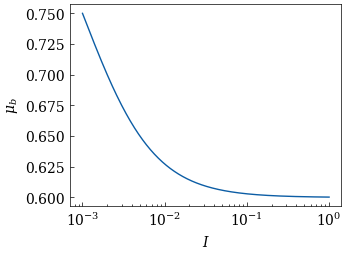

In [7]:
I = np.linspace(1e-3, 1, 10000)
mu = 0.2 + (0.8-0.2)/(1e-3/I + 1)
mu_b = 1-mu/2


plt.figure()
plt.plot(I, mu_b)
plt.xscale('log')
plt.xlabel(r'$I$')
plt.ylabel(r'$\mu_b$')
